In [146]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import CategoricalNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import GaussianNB

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import OrdinalEncoder
import random
random.seed(9)

In [147]:
path="/Users/mattgonzales/Downloads/Labeled Turnips - turnip_weekly_clean.csv"

In [148]:
turnip=pd.read_csv(path)
turnip = turnip.dropna()
turnip.isna().sum()

week            0
Sunday_AM       0
Monday_AM       0
Monday_PM       0
Tuesday_AM      0
Tuesday_PM      0
Wednesday_AM    0
Wednesday_PM    0
Thursday_AM     0
Thursday_PM     0
Friday_AM       0
Friday_PM       0
Saturday_AM     0
Saturday_PM     0
Label           0
dtype: int64

In [149]:
model = GaussianNB()

In [150]:
price_cols = turnip.columns[1:-1]  # all price columns

In [151]:
price_cols

Index(['Sunday_AM', 'Monday_AM', 'Monday_PM', 'Tuesday_AM', 'Tuesday_PM',
       'Wednesday_AM', 'Wednesday_PM', 'Thursday_AM', 'Thursday_PM',
       'Friday_AM', 'Friday_PM', 'Saturday_AM', 'Saturday_PM'],
      dtype='object')

In [152]:
X = turnip[price_cols] 

In [153]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(turnip['Label'])

In [154]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model_g = GaussianNB()
model_g.fit(X_train, y_train)

y_pred_g = model_g.predict(X_test)

In [155]:
print("X Training:\n", X_train)

X Training:
      Sunday_AM  Monday_AM  Monday_PM  Tuesday_AM  Tuesday_PM  Wednesday_AM  \
99       107.0       93.0       88.0        83.0          79            74   
71       100.0       87.0       82.0        78.0          73            69   
90        99.0       86.0       83.0        79.0          76            72   
92       109.0       97.0       92.0        89.0          84           128   
2        106.0       96.0       91.0        86.0          83            79   
..         ...        ...        ...         ...         ...           ...   
102       95.0       68.0       65.0        62.0          92           126   
29       103.0       91.0       87.0        82.0          78            73   
33        90.0       78.0       75.0        71.0          67            63   
81        94.0       93.0      129.0        86.0          68            63   
54       103.0      119.0       80.0        74.0         125           140   

     Wednesday_PM  Thursday_AM  Thursday_PM  Frida

In [156]:
print("X Testing:\n", X_test)

X Testing:
      Sunday_AM  Monday_AM  Monday_PM  Tuesday_AM  Tuesday_PM  Wednesday_AM  \
94       104.0       89.0       85.0        80.0          77            73   
77       106.0       74.0       96.0       118.0         149           153   
44        98.0       87.0       83.0        89.0         175           446   
41       103.0       91.0       87.0        84.0          79           104   
108      103.0      110.0      138.0       118.0         108           144   
101      100.0       90.0       87.0        83.0          79            74   
51       109.0      112.0       84.0        74.0          63           135   
28       105.0       52.0       48.0        45.0          40           121   
1        109.0       88.0       84.0        80.0          76            73   
66       102.0      107.0      140.0       122.0          96           137   
62       110.0       95.0       92.0        88.0          83            78   
13        99.0       87.0       82.0        78.0    

In [157]:
print("Y Training:\n", y_train)

Y Training:
 [0 0 3 2 0 1 3 2 1 0 1 2 1 1 3 0 0 1 0 1 0 2 2 3 0 3 3 2 2 1 1 1 2 1 2 1 2
 3 3 0 2 2 1 0 2 1 1 1 2 3 1 1 0 3 2 1 0 1 3 3 3 1 1 1 1 3 1 2 3 2 3 3 3 2
 2 3 2 2 3 2 2 1 1]


In [158]:
print("Y Testing:\n", y_test)

Y Testing:
 [0 3 2 2 1 0 1 3 3 1 0 0 1 3 2 2 0 0 0 2 0]


In [159]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_g))
print(classification_report(y_test, y_pred_g))

Accuracy: 0.9523809523809523
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       0.80      1.00      0.89         4
           2       1.00      1.00      1.00         5
           3       1.00      0.75      0.86         4

    accuracy                           0.95        21
   macro avg       0.95      0.94      0.94        21
weighted avg       0.96      0.95      0.95        21



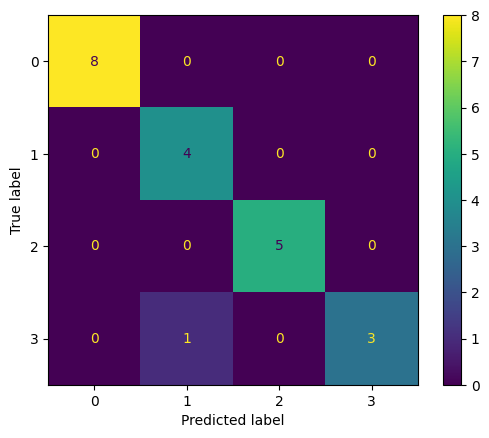

In [161]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_g)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()